# The Magic of $Av = \lambda v$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define a 2x2 Transformation Matrix
A = np.array([[3, 1],
              [0, 2]])

# Calculate Eigenvalues (w) and Eigenvectors (v)
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:\n", A)
print("\nEigenvalues (λ):", eigenvalues)
print("Eigenvectors (v):\n", eigenvectors)

# Let's prove Av = λv for the first eigenvector
v1 = eigenvectors[:, 0]
lambda_1 = eigenvalues[0]

# Left side: Matrix multiplication (A @ v)
left_side = A @ v1

# Right side: Scalar multiplication (λ * v)
right_side = lambda_1 * v1

print("\nProof of Av = λv:")
print(f"A @ v1:      {left_side}")
print(f"λ1 * v1:     {right_side}")
# They match exactly!

Matrix A:
 [[3 1]
 [0 2]]

Eigenvalues (λ): [3. 2.]
Eigenvectors (v):
 [[ 1.         -0.70710678]
 [ 0.          0.70710678]]

Proof of Av = λv:
A @ v1:      [3. 0.]
λ1 * v1:     [3. 0.]


## Visualizing the Eigenvectors

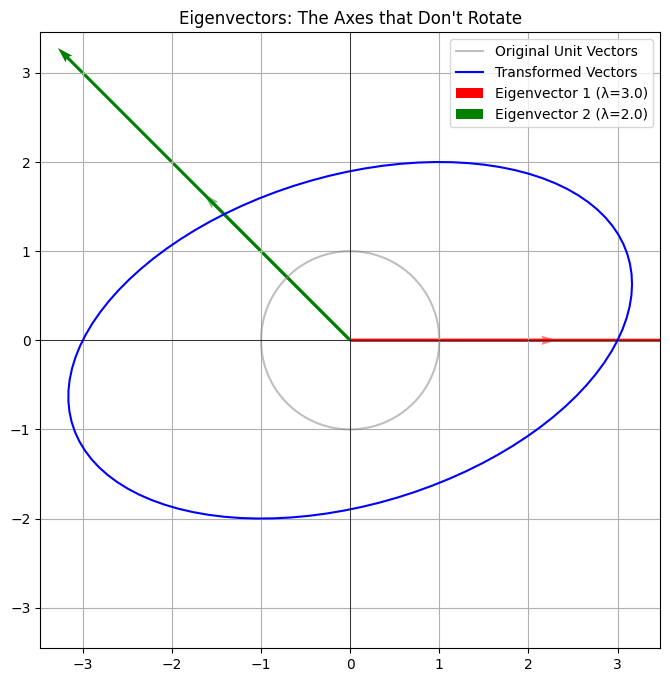

In [2]:
def plot_eigenvectors(A, eigenvectors):
    # Create a circle of unit vectors
    angles = np.linspace(0, 2 * np.pi, 100)
    circle = np.array([np.cos(angles), np.sin(angles)])

    # Apply transformation to the circle (turns it into an ellipse)
    transformed_circle = A @ circle

    plt.figure(figsize=(8, 8))
    # Plot original circle and transformed ellipse
    plt.plot(circle[0, :], circle[1, :], color='gray', alpha=0.5, label='Original Unit Vectors')
    plt.plot(transformed_circle[0, :], transformed_circle[1, :], color='blue', label='Transformed Vectors')

    # Plot the Eigenvectors
    colors = ['red', 'green']
    for i in range(len(eigenvalues)):
        v = eigenvectors[:, i]
        lam = eigenvalues[i]

        # Original eigenvector
        plt.quiver(0, 0, v[0], v[1], color=colors[i], scale=3, width=0.005, alpha=0.5)
        # Transformed eigenvector (scaled by eigenvalue)
        plt.quiver(0, 0, v[0] * lam, v[1] * lam, color=colors[i], scale=3, width=0.005,
                   label=f'Eigenvector {i+1} (λ={lam:.1f})')

    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.title("Eigenvectors: The Axes that Don't Rotate")
    plt.legend()
    plt.grid()
    plt.axis('equal')
    plt.show()

plot_eigenvectors(A, eigenvectors)